In [1]:
!pip install pandas matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [3]:
base_dir = "."
cleaned_csv_dir = os.path.join(base_dir, "cleaned_csv")

os.makedirs(cleaned_csv_dir, exist_ok=True)

print("cleaned_csv_dir:", cleaned_csv_dir)

cleaned_csv_dir: .\cleaned_csv


In [4]:
input_file = "../01_scraping/raw_csv/dataset1_raw_youtube.csv"
df = pd.read_csv(input_file)

print("Raw rows:", len(df))
print(df.columns.tolist())
display(df.head())

Raw rows: 373
['query', 'video_id', 'title', 'channel', 'duration', 'view_count', 'upload_date', 'url', 'webpage_url']


,query,video_id,title,channel,duration,view_count,upload_date,url,webpage_url
0,bird warning call,dvK-DujvpSY,White bellbird: listen to the world's loudest ...,Guardian News,31.0,9885069.0,NaN,https://www.youtube.com/watch?v=dvK-DujvpSY,NaN
1,bird warning call,cPIIVjkp7k0,Bluebird Alarm Call,Wild Birds Unlimited Macomb,12.0,26065.0,NaN,https://www.youtube.com/watch?v=cPIIVjkp7k0,NaN
2,bird warning call,ga_Ybn_K4rc,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub,29.0,13511.0,NaN,https://www.youtube.com/watch?v=ga_Ybn_K4rc,NaN
3,bird warning call,uuxTZN98rHI,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie,96.0,30788.0,NaN,https://www.youtube.com/watch?v=uuxTZN98rHI,NaN
4,bird warning call,07zi6M7sCJQ,Hawk sounds to scare birds 🦅 7 hours,PMnaturaly,25333.0,651426.0,NaN,https://www.youtube.com/watch?v=07zi6M7sCJQ,NaN


In [5]:
text_cols = ["query", "title", "channel", "url", "webpage_url", "upload_date"]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
query          0
video_id       0
title          0
channel        0
duration       3
view_count     3
upload_date    0
url            0
webpage_url    0
dtype: int64


In [6]:
def normalize_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"[\n\r\t]+", " ", x)
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()

df["query_clean"] = df["query"].apply(normalize_text)
df["title_clean"] = df["title"].apply(normalize_text)
df["channel_clean"] = df["channel"].apply(normalize_text)

display(df[["query", "title", "title_clean"]].head())

,query,title,title_clean
0,bird warning call,White bellbird: listen to the world's loudest ...,white bellbird listen to the world s loudest b...
1,bird warning call,Bluebird Alarm Call,bluebird alarm call
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),chickadee alarm call 16 alarm call at the end
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",5 bird alarm calls blackbird wren blackcap thr...
4,bird warning call,Hawk sounds to scare birds 🦅 7 hours,hawk sounds to scare birds 7 hours


In [7]:
df = df[df["title_clean"] != ""].copy().reset_index(drop=True)
df = df.drop_duplicates(subset=["video_id"]).reset_index(drop=True)

print("Rows after removing empty titles and duplicate video_id:", len(df))

Rows after removing empty titles and duplicate video_id: 373


In [8]:
duplicate_titles = df["title_clean"].duplicated().sum()
print("Duplicate cleaned titles:", duplicate_titles)

Duplicate cleaned titles: 3


In [9]:
boundary_keywords = [
    "warning", "alarm", "territorial", "territory", "distress",
    "danger", "alert", "threat", "aggressive", "defensive",
    "predator", "predators", "attack", "panic", "scare"
]

sound_keywords = [
    "call", "calls", "sound", "sounds", "scream", "screams",
    "cry", "cries", "vocal", "vocalization", "noise", "noises"
]

noise_keywords = [
    "beautiful", "iconic", "cute", "funny", "compilation",
    "facts", "for kids", "relax", "relaxing", "sleep",
    "hours", "1 hour", "10 hours", "4k", "hd", "shorts",
    "species", "identification", "documentary", "nature sounds",
    "birds singing", "bird song"
]

In [10]:
def count_keyword_matches(text, keywords):
    text = str(text)
    return sum(1 for kw in keywords if kw in text)

df["boundary_score"] = df["title_clean"].apply(lambda x: count_keyword_matches(x, boundary_keywords))
df["sound_score"] = df["title_clean"].apply(lambda x: count_keyword_matches(x, sound_keywords))
df["noise_score"] = df["title_clean"].apply(lambda x: count_keyword_matches(x, noise_keywords))

display(df[[
    "title",
    "boundary_score",
    "sound_score",
    "noise_score"
]].head(20))

,title,boundary_score,sound_score,noise_score
0,White bellbird: listen to the world's loudest ...,0,1,0
1,Bluebird Alarm Call,1,1,0
2,Chickadee alarm call (16 alarm call at the end!),1,1,0
3,"5 bird alarm calls: blackbird, wren, blackcap,...",1,2,0
4,Hawk sounds to scare birds 🦅 7 hours,1,2,1
5,Bird Calls: Is That An Alarm?,1,2,0
6,Blackbird alarm call,1,1,0
7,Decoding bird calls: What they are REALLY Saying?,0,2,0
8,Loud American Robin Alarm Warning Call - Robin...,2,3,0
9,Anti Birds Repellent Sound - calls of birds of...,1,3,0


In [11]:
df["keep_initial"] = (
    (
        (df["boundary_score"] >= 1)
        | (
            df["query_clean"].str.contains("warning|alarm|territorial")
            & (df["sound_score"] >= 1)
        )
    )
    & (df["noise_score"] == 0)
)

print(df["keep_initial"].value_counts())

keep_initial
True     271
False    102
Name: count, dtype: int64


In [12]:
display(
    df[df["keep_initial"] == True][
        ["query", "title", "channel", "boundary_score", "sound_score", "noise_score"]
    ].head(40)
)

,query,title,channel,boundary_score,sound_score,noise_score
0,bird warning call,White bellbird: listen to the world's loudest ...,Guardian News,0,1,0
1,bird warning call,Bluebird Alarm Call,Wild Birds Unlimited Macomb,1,1,0
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub,1,1,0
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie,1,2,0
5,bird warning call,Bird Calls: Is That An Alarm?,NatureMentor,1,2,0
6,bird warning call,Blackbird alarm call,hebrideanwild,1,1,0
7,bird warning call,Decoding bird calls: What they are REALLY Saying?,Wildlife Wanderings,0,2,0
8,bird warning call,Loud American Robin Alarm Warning Call - Robin...,TheBackyardBirder - Corey Schmaltz,2,3,0
9,bird warning call,Anti Birds Repellent Sound - calls of birds of...,Relax Milleaccendini,1,3,0
10,bird warning call,Cardinal Bird-Calling Sounds promo,Nature Sounds with Songbirds,0,3,0


In [13]:
display(
    df[df["keep_initial"] == False][
        ["query", "title", "channel", "boundary_score", "sound_score", "noise_score"]
    ].head(40)
)

,query,title,channel,boundary_score,sound_score,noise_score
4,bird warning call,Hawk sounds to scare birds 🦅 7 hours,PMnaturaly,1,2,1
26,bird warning call,UK Garden Bird Identification Guide - Bird Nam...,My Birding Year,0,0,1
29,bird warning call,Results from a mobbing recording of an Eastern...,Paul Martin (The Bird Nerd),0,0,0
33,bird warning call,25 Iconic Bird Sounds,Navarre's Wild Shots,0,2,1
34,bird warning call,10 Common Backyard Bird Songs of the Eastern US,Navarre's Wild Shots,0,0,1
36,bird warning call,Gangland Big Bird,breerex123,0,0,0
53,bird warning call,Drongo Bird Tricks Meerkats | Africa | BBC Earth,BBC Earth,0,0,0
54,bird warning call,"Northern Mockingbird Bird Sound, Bird Song, Bi...",Green field,0,2,1
55,bird warning call,Learn 25 Nocturnal Bird Songs and Calls (Unite...,Badgerland Birding,0,2,1
61,bird warning call,Attenborough: the amazing Lyre Bird sings like...,BBC Earth,0,0,0


In [14]:
selection_log = df[[
    "query",
    "video_id",
    "title",
    "channel",
    "duration",
    "view_count",
    "upload_date",
    "url",
    "webpage_url",
    "query_clean",
    "title_clean",
    "boundary_score",
    "sound_score",
    "noise_score",
    "keep_initial"
]].copy()

selection_log_file = os.path.join(cleaned_csv_dir, "dataset1_selection_log.csv")
selection_log.to_csv(selection_log_file, index=False, encoding="utf-8-sig")

print("Saved file:", selection_log_file)

Saved file: .\cleaned_csv\dataset1_selection_log.csv


In [15]:
df_cleaned = df[df["keep_initial"] == True].copy().reset_index(drop=True)

print("Raw rows:", len(df))
print("Cleaned rows:", len(df_cleaned))

display(df_cleaned.head())

Raw rows: 373
Cleaned rows: 271


,query,video_id,title,channel,duration,view_count,upload_date,url,webpage_url,query_clean,title_clean,channel_clean,boundary_score,sound_score,noise_score,keep_initial
0,bird warning call,dvK-DujvpSY,White bellbird: listen to the world's loudest ...,Guardian News,31.0,9885069.0,,https://www.youtube.com/watch?v=dvK-DujvpSY,,bird warning call,white bellbird listen to the world s loudest b...,guardian news,0,1,0,True
1,bird warning call,cPIIVjkp7k0,Bluebird Alarm Call,Wild Birds Unlimited Macomb,12.0,26065.0,,https://www.youtube.com/watch?v=cPIIVjkp7k0,,bird warning call,bluebird alarm call,wild birds unlimited macomb,1,1,0,True
2,bird warning call,ga_Ybn_K4rc,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub,29.0,13511.0,,https://www.youtube.com/watch?v=ga_Ybn_K4rc,,bird warning call,chickadee alarm call 16 alarm call at the end,bird feeder hub,1,1,0,True
3,bird warning call,uuxTZN98rHI,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie,96.0,30788.0,,https://www.youtube.com/watch?v=uuxTZN98rHI,,bird warning call,5 bird alarm calls blackbird wren blackcap thr...,watch the birdie,1,2,0,True
4,bird warning call,2aFIujmqJfI,Bird Calls: Is That An Alarm?,NatureMentor,369.0,2894.0,,https://www.youtube.com/watch?v=2aFIujmqJfI,,bird warning call,bird calls is that an alarm,naturementor,1,2,0,True


In [16]:
cleaned_file = os.path.join(cleaned_csv_dir, "dataset1_cleaned.csv")
df_cleaned.to_csv(cleaned_file, index=False, encoding="utf-8-sig")

print("Saved file:", cleaned_file)

Saved file: .\cleaned_csv\dataset1_cleaned.csv


In [17]:
query_counts_cleaned = df_cleaned["query"].value_counts().reset_index()
query_counts_cleaned.columns = ["query", "count"]

display(query_counts_cleaned)

,query,count
0,bird warning call,70
1,alarm call animal,65
2,territorial animal sound,63
3,animal warning sound urban,45
4,territorial bird call,28


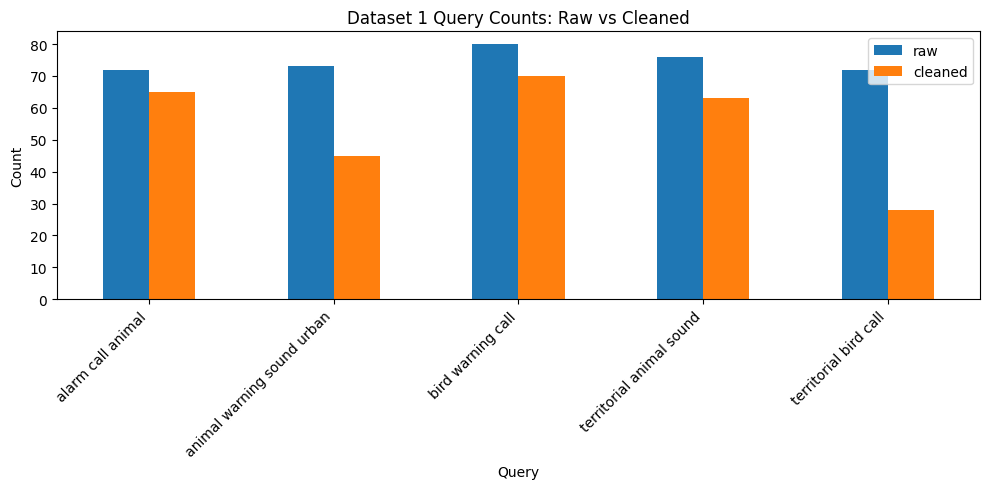

In [18]:
raw_counts = df["query"].value_counts()
clean_counts = df_cleaned["query"].value_counts()

comparison_df = pd.DataFrame({
    "raw": raw_counts,
    "cleaned": clean_counts
}).fillna(0)

comparison_df = comparison_df.sort_index()

comparison_df.plot(kind="bar", figsize=(10, 5))
plt.title("Dataset 1 Query Counts: Raw vs Cleaned")
plt.xlabel("Query")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
display(df_cleaned[["query", "title", "channel"]].sample(min(20, len(df_cleaned)), random_state=42))

,query,title,channel
30,bird warning call,Bird Calls Of Warning Other Birds Of Danger,[Culture Snap]
116,alarm call animal,Alarm call #snake /Snake presence activate al...,Mountain Canopy
79,territorial bird call,"10 Arizona Bird Sounds, Desert Bird Calls",Navarre's Wild Shots
127,alarm call animal,Animal alarm calls of the Sri Lankan dry zone ...,Wildlife with Malmi
196,animal warning sound urban,Siren Head - Sound Effect,TheSovereignShark
137,alarm call animal,Francolin alarm calling at a leopard sighting,Our Life In Africa
209,territorial animal sound,Lions Roaring and Marking Territory | Kruger N...,MacKruger Wildlife Videos
45,bird warning call,Grey Go-Away-Bird Call - The comical 'Go Away'...,Wild Ambience
158,alarm call animal,Alarm call modification by prairie dogs in the...,Journal of Ethology
247,territorial animal sound,Incredible Red Crested Korhaan territorial sou...,Experience Africa Safaris


In [20]:
print("Final cleaned rows:", len(df_cleaned))
print("\nQuery distribution after cleaning:")
print(df_cleaned["query"].value_counts())

print("\nDuplicate cleaned titles:", df_cleaned["title_clean"].duplicated().sum())

Final cleaned rows: 271

Query distribution after cleaning:
query
bird warning call             70
alarm call animal             65
territorial animal sound      63
animal warning sound urban    45
territorial bird call         28
Name: count, dtype: int64

Duplicate cleaned titles: 2


In [21]:
df_cleaned_final = df_cleaned.copy()

print("Before final cleanup:", len(df_cleaned_final))

Before final cleanup: 271


In [22]:
manual_drop_titles = [
    "Siren Head - Sound Effect",
    "Animal Sounds | Sub Urban Ambience With Birds, Animal Sound Effects, Wildlife | 3 Hours",
    "The 8 Most Territorial Animals Known To Humans",
    "25 Iconic Bird Sounds",
    "10 Arizona Bird Sounds, Desert Bird Calls",
    "Squirrel sounds and their meanings",
    "Animal alarm calls of the Sri Lankan dry zone and corresponding predators of Sri Lankan dry zone",
    "The Big Five Uk Owls |  And How to Recognise them by Sight and Sound"
]

df_cleaned_final = df_cleaned_final[
    ~df_cleaned_final["title"].isin(manual_drop_titles)
].copy().reset_index(drop=True)

print("After manual title drop:", len(df_cleaned_final))

After manual title drop: 267


In [23]:
df_cleaned_final = df_cleaned_final.drop_duplicates(subset=["title_clean"]).reset_index(drop=True)

print("After removing duplicate cleaned titles:", len(df_cleaned_final))
print("Remaining duplicate cleaned titles:", df_cleaned_final["title_clean"].duplicated().sum())

After removing duplicate cleaned titles: 265
Remaining duplicate cleaned titles: 0


In [24]:
final_query_counts = df_cleaned_final["query"].value_counts().reset_index()
final_query_counts.columns = ["query", "count"]

display(final_query_counts)

,query,count
0,bird warning call,69
1,alarm call animal,65
2,territorial animal sound,61
3,animal warning sound urban,43
4,territorial bird call,27


In [25]:
final_cleaned_file = os.path.join(cleaned_csv_dir, "dataset1_cleaned_final.csv")
df_cleaned_final.to_csv(final_cleaned_file, index=False, encoding="utf-8-sig")

print("Saved file:", final_cleaned_file)
print("Final cleaned rows:", len(df_cleaned_final))

Saved file: .\cleaned_csv\dataset1_cleaned_final.csv
Final cleaned rows: 265


In [26]:
display(df_cleaned_final[["query", "title", "channel"]].sample(min(20, len(df_cleaned_final)), random_state=42))

,query,title,channel
179,animal warning sound urban,Barking dogs and urban traffic sound effect,Random Sounds HBAM
115,alarm call animal,"Alarm Calls, Crying Wolf, Referential & Affere...",Wildlifehub Pakistan
96,alarm call animal,Monkeys Sound Alarm To Save Deer From A Tiger ...,BBC Earth
24,bird warning call,Bird making Samsung notification sounds,Pascal Parraguez
9,bird warning call,Cardinal Bird-Calling Sounds promo,Nature Sounds with Songbirds
139,alarm call animal,The Inconvenient Alarm Call,Alex & Renias
255,territorial animal sound,A minor territorial dispute breaks out between...,Our World’s Sounds - Topic
45,bird warning call,Predator Hunting Call - Distressed Woodpecker ...,Hotrods & Hunting
185,animal warning sound urban,African Goose Honking - Is this how dinos soun...,Urban Nature
125,alarm call animal,Animal alarm calls of the Sri Lankan dry zone ...,Wildlife with Malmi
